# Validation and Performance of the 137 MHz MWA AEE Model

This notebook compares the `mwa_jaxbeam` 137 MHz Average Embedded Element (AEE)
beam model against the reference implementation in `pyuvdata`, and benchmarks
JAX-compiled forward and gradient evaluations.

Detailed behavioral and regression checks live in the automated `pytest` suite.
The notebook is intentionally limited to:

1. a numerical comparison at representative sky directions;
2. a full visible-hemisphere HEALPix comparison; and
3. performance benchmarks for inference-oriented workloads.


## 1. Setup

In [1]:
from pathlib import Path
import time

import cmasher as cmr
import healpy as hp
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from pyuvdata import UVBeam

from mwa_jaxbeam import jones, power


FREQUENCY_HZ = 137e6
NSIDE = 32
POWER_FLOOR_DB = -60.0

# Resolve reference-data paths whether the notebook is run from the repository
# root or from the notebooks directory.
cwd = Path.cwd()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd
jmatrix_path = repo_root / "data" / "Jmatrix.fits"
zmatrix_path = repo_root / "data" / "ZMatrix.fits"

for path in (jmatrix_path, zmatrix_path):
    if not path.exists():
        raise FileNotFoundError(f"Reference file not found: {path}")

beam_cmap = LinearSegmentedColormap.from_list(
    "pride",
    cmr.pride(np.linspace(0.1, 0.8, 256)),
)
beam_cmap.set_under("white")

print(f"JAX backend: {jax.default_backend()}")
print(f"JAX devices: {jax.devices()}")


JAX backend: cpu
JAX devices: [CpuDevice(id=0)]


### Coordinate convention

`mwa_jaxbeam` measures azimuth from North through East. The native `UVBeam`
azimuth convention used here is measured from East through North, so

$$
\mathrm{az}_{\mathrm{pyuvdata}}
=
\left(
\frac{\pi}{2}
-
\mathrm{az}_{\mathrm{jax}}
\right)
\bmod 2\pi.
$$

In [2]:
def to_pyuvdata_azimuth(az_rad):
    """Convert North-through-East azimuth to East-through-North azimuth."""
    return np.mod(np.pi / 2.0 - np.asarray(az_rad), 2.0 * np.pi)


def interpolate_pyuvdata_efield(beam, az_rad, za_rad):
    """Interpolate the pyuvdata E-field at 137 MHz."""
    result = beam.interp(
        az_array=np.asarray(az_rad),
        za_array=np.asarray(za_rad),
        freq_array=np.array([FREQUENCY_HZ]),
        return_basis_vector=False,
        check_azza_domain=True,
    )
    efield = result[0] if isinstance(result, tuple) else result
    return np.asarray(efield)[:, :, 0, :]


def efield_to_power(efield):
    """Convert an E-field Jones response to XX and YY power."""
    return np.sum(np.abs(efield) ** 2, axis=0)


def power_to_db(values, floor_db=POWER_FLOOR_DB):
    """Convert linear power to decibels with a plotting floor."""
    floor = 10.0 ** (floor_db / 10.0)
    return 10.0 * np.log10(np.maximum(values, floor))


## 2. Load the pyuvdata reference model

In [4]:
aee_beam = UVBeam()

aee_beam.read_mwa_beam(
    jmatrix_path,
    zfile=zmatrix_path,
    delays=np.zeros((2, 16), dtype=int),
    amplitudes=np.ones((2, 16), dtype=float),
    include_cross_feed_coupling=True,
)

max_za_rad = float(np.max(aee_beam.axis2_array))

print(f"Beam type: {aee_beam.beam_type}")
print(f"Coordinate system: {aee_beam.pixel_coordinate_system}")
print(f"Frequency range: {aee_beam.freq_array[[0, -1]] / 1e6} MHz")
print(f"Maximum zenith angle: {np.rad2deg(max_za_rad):.1f} deg")

Beam type: efield
Coordinate system: az_za
Frequency range: [ 72.96 239.36] MHz
Maximum zenith angle: 90.0 deg


In [5]:
# Normalize each feed by its exact-zenith response.
pyuv_zenith_efield = interpolate_pyuvdata_efield(
    aee_beam,
    az_rad=np.array([np.pi / 2.0]),
    za_rad=np.array([0.0]),
)
pyuv_zenith_power = efield_to_power(pyuv_zenith_efield)[:, 0]

print("pyuvdata zenith power:", pyuv_zenith_power)

pyuvdata zenith power: [1.84209469 1.84209248]


## 3. Cardinal-direction comparison

In [6]:
direction_names = ("North", "East", "South", "West")
az_jax = np.deg2rad([0.0, 90.0, 180.0, 270.0])
za_rad = np.deg2rad(np.full(4, 30.0))

jax_cardinal_power = np.asarray(
    power(
        az_rad=az_jax,
        za_rad=za_rad,
        normalize=True,
    )
)

pyuv_cardinal_efield = interpolate_pyuvdata_efield(
    aee_beam,
    az_rad=to_pyuvdata_azimuth(az_jax),
    za_rad=za_rad,
)
pyuv_cardinal_power = (
    efield_to_power(pyuv_cardinal_efield)
    / pyuv_zenith_power[:, np.newaxis]
)

print(f"{'Feed':<5} {'Direction':<10} {'JAX':>12} {'pyuvdata':>12} {'Residual [dB]':>16}")
print("-" * 61)

for feed, feed_name in enumerate(("XX", "YY")):
    for index, direction in enumerate(direction_names):
        residual_db = 10.0 * np.log10(
            jax_cardinal_power[feed, index]
            / pyuv_cardinal_power[feed, index]
        )
        print(
            f"{feed_name:<5} {direction:<10} "
            f"{jax_cardinal_power[feed, index]:12.6f} "
            f"{pyuv_cardinal_power[feed, index]:12.6f} "
            f"{residual_db:16.4f}"
        )


Feed  Direction           JAX     pyuvdata    Residual [dB]
-------------------------------------------------------------
XX    North          0.000076     0.000076          -0.0070
XX    East           0.000094     0.000094           0.0042
XX    South          0.000076     0.000076          -0.0065
XX    West           0.000094     0.000094           0.0043
YY    North          0.000094     0.000094           0.0039
YY    East           0.000076     0.000076          -0.0067
YY    South          0.000094     0.000094           0.0035
YY    West           0.000076     0.000076          -0.0070


## 4. Full visible-hemisphere comparison

Both implementations are evaluated at the same $N_{\mathrm{side}}=32$
HEALPix pixel centres. The residual is

$$
\Delta P =
10\log_{10}P_{\mathrm{JAX}}
-
10\log_{10}P_{\mathrm{pyuvdata}}.
$$


In [7]:
npix = hp.nside2npix(NSIDE)
pixel_indices = np.arange(npix)
za_hpx, phi_hpx = hp.pix2ang(NSIDE, pixel_indices)

# HEALPix phi is East-through-North. Convert it to the package convention.
az_jax_hpx = np.mod(np.pi / 2.0 - phi_hpx, 2.0 * np.pi)
az_pyuvdata_hpx = to_pyuvdata_azimuth(az_jax_hpx)

visible = za_hpx <= max_za_rad
n_visible = int(np.count_nonzero(visible))

print(f"HEALPix pixels: {npix}")
print(f"Compared pixels: {n_visible}")

HEALPix pixels: 12288
Compared pixels: 6208


In [8]:
jax_power_hpx = np.full((2, npix), np.nan, dtype=float)
jax_power_hpx[:, visible] = np.asarray(
    power(
        az_rad=az_jax_hpx[visible],
        za_rad=za_hpx[visible],
        normalize=True,
    )
)

pyuv_efield_visible = interpolate_pyuvdata_efield(
    aee_beam,
    az_rad=az_pyuvdata_hpx[visible],
    za_rad=za_hpx[visible],
)
pyuv_power_visible = (
    efield_to_power(pyuv_efield_visible)
    / pyuv_zenith_power[:, np.newaxis]
)

pyuv_power_hpx = np.full((2, npix), np.nan, dtype=float)
pyuv_power_hpx[:, visible] = pyuv_power_visible

jax_power_db = power_to_db(jax_power_hpx)
pyuv_power_db = power_to_db(pyuv_power_hpx)

residual_db = 10.0 * np.log10(
    np.maximum(jax_power_hpx, np.finfo(float).tiny)
    / np.maximum(pyuv_power_hpx, np.finfo(float).tiny)
)

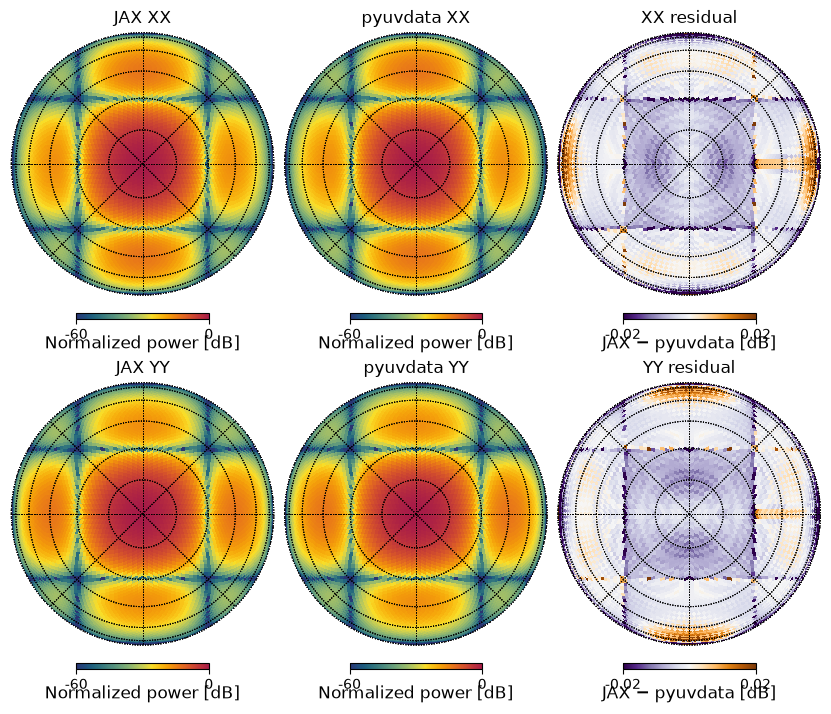

In [10]:
def as_healpix_map(values):
    """Replace non-finite values with HEALPix's unseen sentinel."""
    result = np.full(values.shape, hp.UNSEEN, dtype=float)
    finite = np.isfinite(values)
    result[finite] = values[finite]
    return result


jax_maps = as_healpix_map(jax_power_db)
pyuv_maps = as_healpix_map(pyuv_power_db)
residual_maps = as_healpix_map(residual_db)

fig = plt.figure(figsize=(8.2, 7.0))

beam_kwargs = {
    "rot": (0, 90, -90),
    "half_sky": True,
    "flip": "geo",
    "fig": fig,
    "min": POWER_FLOOR_DB,
    "max": 0.0,
    "unit": "\n\nNormalized power [dB]",
    "badcolor": "whitesmoke",
    "cmap": beam_cmap,
}
residual_kwargs = {
    "rot": (0, 90, -90),
    "half_sky": True,
    "flip": "geo",
    "fig": fig,
    "min": -0.02,
    "max": 0.02,
    "unit": "\n\nJAX − pyuvdata [dB]",
    "cmap": "PuOr_r",
}

for row, feed_name in enumerate(("XX", "YY")):
    hp.orthview(
        jax_maps[row],
        sub=(2, 3, 1 + 3 * row),
        title=f"JAX {feed_name}",
        **beam_kwargs,
    )
    hp.orthview(
        pyuv_maps[row],
        sub=(2, 3, 2 + 3 * row),
        title=f"pyuvdata {feed_name}",
        **beam_kwargs,
    )
    hp.orthview(
        residual_maps[row],
        sub=(2, 3, 3 + 3 * row),
        title=f"{feed_name} residual",
        **residual_kwargs,
    )

for _ in range(6):
    hp.graticule(dpar=15, dmer=45, ls=":", lw=0.7, alpha=0.7)

plt.show()

### Residual statistics

In [11]:
comparison_mask = (
    visible[np.newaxis, :]
    & (jax_power_db > POWER_FLOOR_DB)
    & (pyuv_power_db > POWER_FLOOR_DB)
)

print(f"{'Feed':<5} {'N':>8} {'Mean [dB]':>12} {'Std [dB]':>12} {'RMS [dB]':>12} {'Max |Δ| [dB]':>14}")
print("-" * 70)

for feed, feed_name in enumerate(("XX", "YY")):
    values = residual_db[feed, comparison_mask[feed]]
    print(
        f"{feed_name:<5} {values.size:8d} "
        f"{np.mean(values):12.4f} "
        f"{np.std(values):12.4f} "
        f"{np.sqrt(np.mean(values**2)):12.4f} "
        f"{np.max(np.abs(values)):14.4f}"
    )

Feed         N    Mean [dB]     Std [dB]     RMS [dB]   Max |Δ| [dB]
----------------------------------------------------------------------
XX        5682      -0.0063       0.0199       0.0209         0.2721
YY        5682      -0.0064       0.0197       0.0207         0.2722


## 5. Performance benchmarks

The first call includes JAX tracing and compilation. Subsequent timings measure
compiled execution. Results are hardware- and backend-dependent.


In [12]:
MAX_BENCHMARK_DIRECTIONS = 12_288
BENCHMARK_SIZES = (48, 192, 768, 3_072, 6_144, 12_288)

# Deterministic directions distributed over the visible hemisphere.
index = np.arange(MAX_BENCHMARK_DIRECTIONS)
golden_angle = np.pi * (3.0 - np.sqrt(5.0))
az_benchmark = jnp.asarray(np.mod(index * golden_angle, 2.0 * np.pi))
za_benchmark = jnp.asarray(
    np.arccos(1.0 - (index + 0.5) / MAX_BENCHMARK_DIRECTIONS)
)

excitations = jnp.ones((2, 16), dtype=jnp.complex64)
jones_jit = jax.jit(jones)


def time_compiled(function, *args, iterations):
    """Return mean wall-clock time for an already-compiled JAX function."""
    result = function(*args)
    jax.block_until_ready(result)

    start = time.perf_counter()
    for _ in range(iterations):
        result = function(*args)
    jax.block_until_ready(result)

    return (time.perf_counter() - start) / iterations


### 5.1 Forward Jones evaluation

In [13]:
start = time.perf_counter()
compiled_result = jones_jit(
    az_benchmark[:6_144],
    za_benchmark[:6_144],
    excitations,
)
jax.block_until_ready(compiled_result)
forward_compile_time = time.perf_counter() - start

forward_time = time_compiled(
    jones_jit,
    az_benchmark[:6_144],
    za_benchmark[:6_144],
    excitations,
    iterations=10_000,
)

print(f"Compilation: {forward_compile_time:.3f} s")
print(f"Compiled evaluation: {forward_time * 1e3:.3f} ms")
print(f"Throughput: {1.0 / forward_time:.1f} evaluations/s")


Compilation: 0.164 s
Compiled evaluation: 0.499 ms
Throughput: 2004.4 evaluations/s


In [14]:
print(f"{'Directions':>12} {'Time [ms]':>12} {'Time/direction [μs]':>22}")
print("-" * 50)

for size in BENCHMARK_SIZES:
    elapsed = time_compiled(
        jones_jit,
        az_benchmark[:size],
        za_benchmark[:size],
        excitations,
        iterations=200,
    )
    print(f"{size:12d} {elapsed * 1e3:12.3f} {elapsed / size * 1e6:22.3f}")


  Directions    Time [ms]    Time/direction [μs]
--------------------------------------------------
          48        0.042                  0.877
         192        0.062                  0.324
         768        0.124                  0.161
        3072        0.347                  0.113
        6144        0.511                  0.083
       12288        0.876                  0.071


### 5.2 Loss and gradient evaluation

In [15]:
def loss(excitations, az_rad, za_rad):
    """Synthetic inference loss used only for benchmarking autodiff."""
    beam = jones(
        az_rad=az_rad,
        za_rad=za_rad,
        excitations=excitations,
    )
    xx_power = jnp.abs(beam[0, 0]) ** 2
    target = jnp.ones_like(xx_power)
    return jnp.mean((xx_power - target) ** 2)


loss_and_grad = jax.jit(jax.value_and_grad(loss))

start = time.perf_counter()
compiled_loss = loss_and_grad(
    excitations,
    az_benchmark[:6_144],
    za_benchmark[:6_144],
)
jax.block_until_ready(compiled_loss)
gradient_compile_time = time.perf_counter() - start

gradient_time = time_compiled(
    loss_and_grad,
    excitations,
    az_benchmark[:6_144],
    za_benchmark[:6_144],
    iterations=10_000,
)

print(f"Compilation: {gradient_compile_time:.3f} s")
print(f"Compiled loss + gradient: {gradient_time * 1e3:.3f} ms")
print(f"Throughput: {1.0 / gradient_time:.1f} evaluations/s")
print(f"Gradient overhead relative to forward: {gradient_time / forward_time:.2f}×")


Compilation: 0.163 s
Compiled loss + gradient: 0.837 ms
Throughput: 1194.7 evaluations/s
Gradient overhead relative to forward: 1.68×


In [16]:
print(f"{'Directions':>12} {'Time [ms]':>12} {'Time/direction [μs]':>22}")
print("-" * 50)

for size in BENCHMARK_SIZES:
    elapsed = time_compiled(
        loss_and_grad,
        excitations,
        az_benchmark[:size],
        za_benchmark[:size],
        iterations=200,
    )
    print(f"{size:12d} {elapsed * 1e3:12.3f} {elapsed / size * 1e6:22.3f}")


  Directions    Time [ms]    Time/direction [μs]
--------------------------------------------------
          48        0.048                  1.008
         192        0.078                  0.406
         768        0.171                  0.223
        3072        0.515                  0.168
        6144        0.818                  0.133
       12288        1.096                  0.089
